# Triage Prediction - OOP Structure

This notebook uses the modular OOP structure for better organization.

In [1]:
# Import modules
import sys
sys.path.append('.')

from config import *
from data_loader import load_data
from preprocessor import DataPreprocessor
from models import ModelTrainer
from evaluator import ModelEvaluator
from visualizer import *

import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# Load data
import os
os.chdir('..')
chief_complaint_data, patient_history_data, train_data, test_data, sample_submission_data = load_data()
print("Data loaded successfully")

Data loaded successfully


In [10]:
# Inspect data
print("Train categorical columns:", train_data.select_dtypes(include=['object']).columns.tolist())
print("Test categorical columns:", test_data.select_dtypes(include=['object']).columns.tolist())
# Check which column has 'TG-FZUFCRZS3'
for col in train_data.select_dtypes(include=['object']).columns:
    if 'TG-FZUFCRZS3' in train_data[col].values:
        print(f"'TG-FZUFCRZS3' found in train {col}")
for col in test_data.select_dtypes(include=['object']).columns:
    if 'TG-FZUFCRZS3' in test_data[col].values:
        print(f"'TG-FZUFCRZS3' found in test {col}")

Train categorical columns: ['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_day', 'arrival_season', 'shift', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'disposition']
Test categorical columns: ['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_day', 'arrival_season', 'shift', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system']
'TG-FZUFCRZS3' found in test patient_id


C:\Users\U-ser\AppData\Local\Temp\ipykernel_13588\3816733170.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Train categorical columns:", train_data.select_dtypes(include=['object']).columns.tolist())
C:\Users\U-ser\AppData\Local\Temp\ipykernel_13588\3816733170.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
Se

In [3]:
# Preprocess data
preprocessor = DataPreprocessor()
X, X_test, y = preprocessor.preprocess(train_data, test_data, chief_complaint_data, patient_history_data)

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Apply SMOTE
X_train_resampled, y_train_resampled = preprocessor.apply_smote(X_train, y_train)
print("Preprocessing complete")

d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [68 69 70 72] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Preprocessing complete


In [4]:
# Train models
trainer = ModelTrainer()
models = trainer.train_models(X_train_resampled, y_train_resampled)
print("Models trained")

Models trained


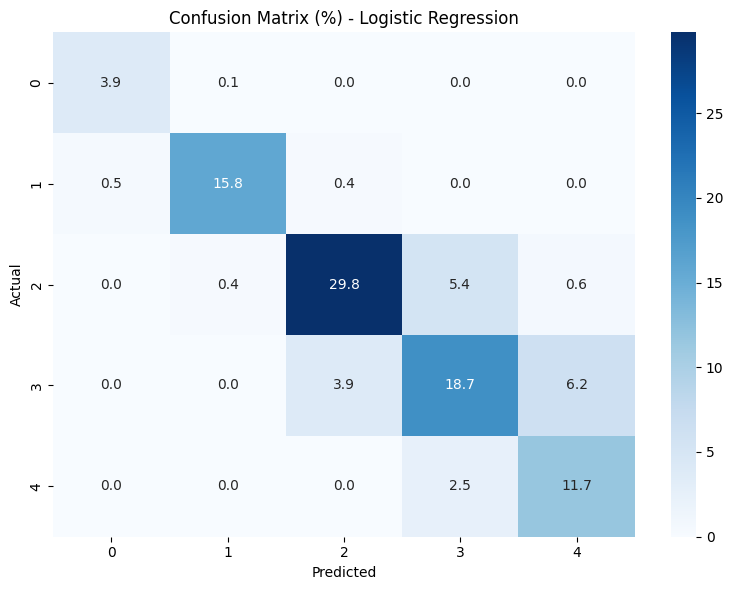

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           1       0.88      0.97      0.92       644
           2       0.97      0.94      0.96      2688
           3       0.87      0.82      0.85      5784
           4       0.70      0.65      0.68      4604
           5       0.63      0.82      0.72      2280

    accuracy                           0.80     16000
   macro avg       0.81      0.84      0.82     16000
weighted avg       0.81      0.80      0.80     16000

5-fold CV F1-Score: 0.797 (+/- 0.005)


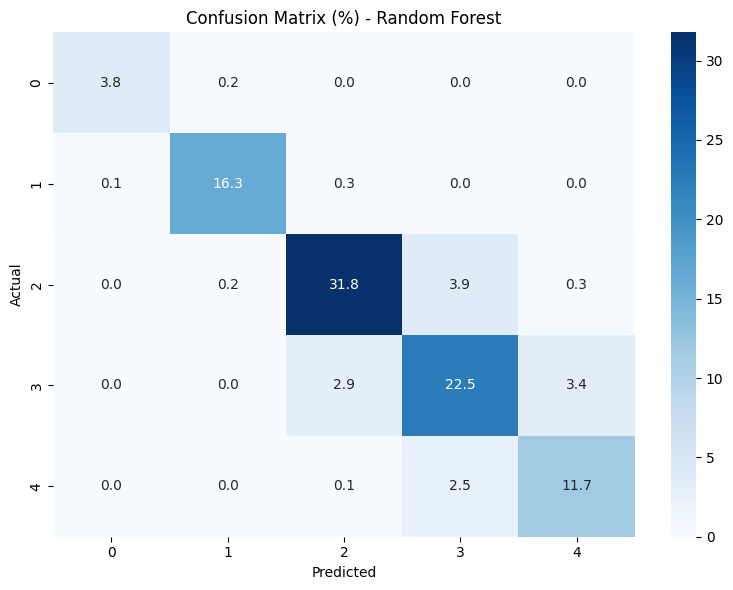

Classification Report for Random Forest:
              precision    recall  f1-score   support

           1       0.96      0.94      0.95       644
           2       0.97      0.97      0.97      2688
           3       0.91      0.88      0.89      5784
           4       0.78      0.78      0.78      4604
           5       0.76      0.82      0.79      2280

    accuracy                           0.86     16000
   macro avg       0.88      0.88      0.88     16000
weighted avg       0.86      0.86      0.86     16000

5-fold CV F1-Score: 0.843 (+/- 0.010)


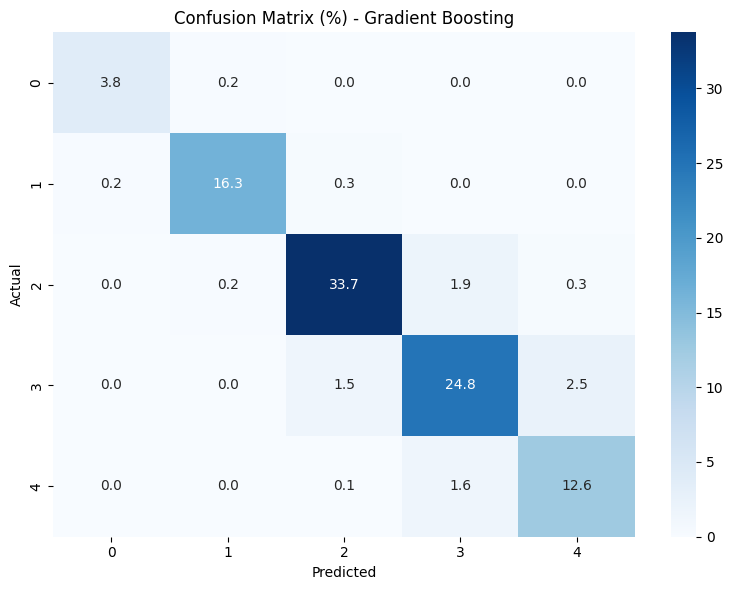

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           1       0.95      0.95      0.95       644
           2       0.97      0.97      0.97      2688
           3       0.95      0.93      0.94      5784
           4       0.88      0.86      0.87      4604
           5       0.82      0.88      0.85      2280

    accuracy                           0.91     16000
   macro avg       0.91      0.92      0.92     16000
weighted avg       0.91      0.91      0.91     16000

5-fold CV F1-Score: 0.931 (+/- 0.008)


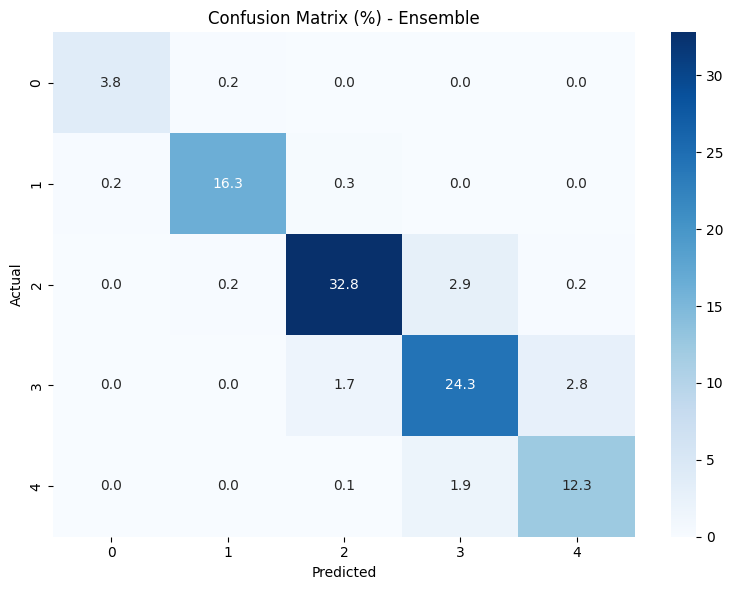

Classification Report for Ensemble:
              precision    recall  f1-score   support

           1       0.96      0.95      0.95       644
           2       0.98      0.97      0.97      2688
           3       0.94      0.91      0.92      5784
           4       0.83      0.84      0.84      4604
           5       0.80      0.86      0.83      2280

    accuracy                           0.90     16000
   macro avg       0.90      0.91      0.90     16000
weighted avg       0.90      0.90      0.90     16000

5-fold CV F1-Score: 0.906 (+/- 0.005)


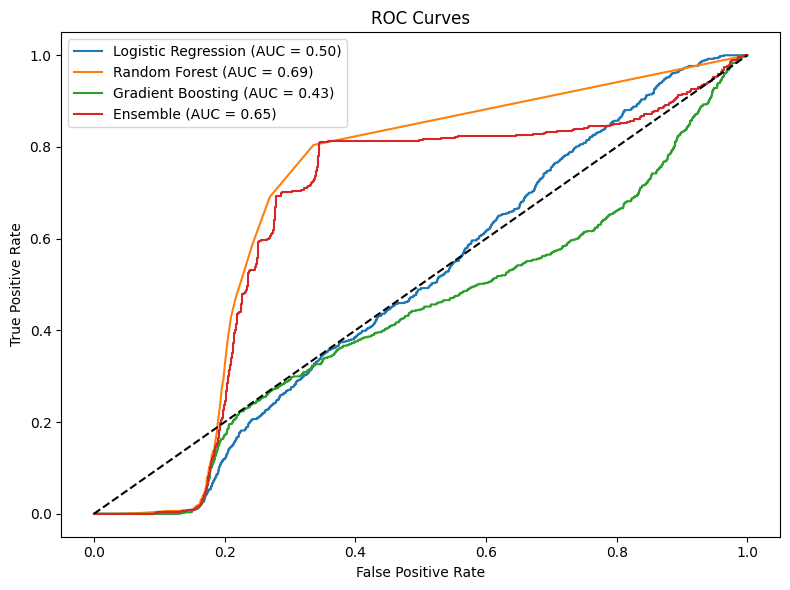

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.799375   0.806476  0.799375  0.800460  0.962299
1        Random Forest  0.860563   0.862310  0.860563  0.861220  0.977941
2    Gradient Boosting  0.911937   0.912954  0.911937  0.912258  0.991002
3             Ensemble  0.895188   0.896983  0.895188  0.895823  0.987255


In [5]:
# Evaluate
evaluator = ModelEvaluator()
results = evaluator.evaluate_models(models, X_val, y_val)
print(results)

In [ ]:
# Learning curve for best model
plot_learning_curve(models['Gradient Boosting'], X_train_resampled, y_train_resampled)